# The Fenty Effect: Modeling U.S. Foundation Shade Ranges Over Time
### COGS 109 Final Project

## Abstract

Foundation shade inclusivity has been a long-standing concern in the beauty industry, and Fenty Beauty’s 2017 launch of a 40-shade line is often cited as a market turning point. We test whether that shift appears in product-level data by modeling how U.S. foundation shade ranges relate to release year. Using a merged dataset with release dates reconstructed from Internet Archive snapshots, we aggregate to the product-line level (**n = 314**) and analyze shade count as the primary outcome. We compare three linear-model specifications of increasing flexibility: (M1) year only, (M2) year plus brand dummies, and (M3) LASSO-regularized year-plus-brand with penalty strength selected by cross-validation. Model selection uses 5-fold cross-validation at the product-line level. M3 achieves the best out-of-sample performance (CV RMSE = 13.152), outperforming M1 (13.218) and substantially improving over the overfit M2 model (14.589). The selected LASSO model retains 19 brand coefficients, indicating meaningful brand-level heterogeneity, and estimates a negative year coefficient in this sample. Under this modeling framework, we do not find support for a positive linear increase in shade count over time. These results suggest that inclusion patterns are strongly brand-dependent and that simple linear time trends may not fully capture post-2017 market dynamics.

## Cell assignments

| Section |
|---|
| Setup, data loading, CV helper |
| **M1**: `shade_count ~ year` |
| **M2**: `shade_count ~ year + brand` |
| **M3**: LASSO on `year + brand` (λ by CV) |
| Model comparison, final refit, discussion |

## Introduction

Foundation shade inclusivity has become a prominent issue in beauty marketing and product design, especially after the 2017 launch of Fenty Beauty’s 40-shade foundation line. This launch is often cited as a market turning point, but we test whether a measurable industry-wide shift appears in product data.

Our dataset combines shade-level records from public beauty retailer/product sources with approximate release dates recovered from the Internet Archive. We aggregate to the **product-line level**, yielding one row per foundation line with three key fields: release year, brand, and shade-range outcomes.

For the primary model in this notebook, the response variable is **shade count** (number of shades in a product line). Predictors are:
- **release_year** (numeric), and
- **brand** (categorical, represented by dummy variables when included).

After preprocessing and required non-missing filters, the analysis sample contains **n = 314 product lines**. In model specifications that include brand fixed effects, there are **p = 104 predictors** total (1 year predictor + 103 brand dummies with one reference brand omitted).

## Background

Historically, many complexion product lines offered narrow shade ranges that disproportionately underserved deeper skin tones. Industry commentary has described the “Fenty Effect” as a competitive response in which brands expanded shade offerings after 2017.

Empirically evaluating this claim requires moving beyond anecdotes. Product-level data with release timing allows us to test whether shade-range breadth changes systematically with release year, and whether those trends remain after controlling for persistent brand differences. This distinction matters because some brands are consistently more inclusive than others regardless of year; without brand adjustment, year effects can be confounded by which brands appear in the sample at different times.

## Hypothesis

Our primary hypothesis is that newer foundation product lines have broader shade ranges than older lines.

Formally, in a regression of shade count on release year (with and without brand controls), we test whether the coefficient on `release_year` is positive:
- **H1:** \(\beta_{\text{year}} > 0\) (shade counts increase over time).
- **H0:** \(\beta_{\text{year}} = 0\) (no linear time trend).

Because brand strategy strongly affects shade breadth, we also compare models with and without brand predictors to evaluate whether apparent time trends persist after accounting for brand-level heterogeneity.

## Methods

The goal is to characterize the relationship between release year and shade count across the industry, not to forecast individual products. We use multiple linear regression as our primary model class because shade count per product line is a roughly continuous outcome and the coefficients are directly interpretable in terms of shades per year. Regression also lets us estimate the year effect while adjusting for brand, separating an industry-wide temporal trend from the fact that some brands are simply more inclusive than others.

We compare three nested specifications by cross-validated error. **M1** predicts shade count from release year alone. **M2** adds 103 brand dummy variables to M1, making it the most flexible of the three but also the most prone to overfitting given only 314 observations. **M3** applies LASSO regularization to M2, adding a penalty λ that shrinks unreliable brand coefficients to zero, effectively doing automatic variable selection. The penalty strength is chosen by cross-validation. We expect M2 to show the highest in-sample R-squared but also the largest gap between training and test error, which is the typical signature of overfitting. M3 should close that gap by dropping brands that do not meaningfully predict shade count.

For cross-validation, we use **k-fold with k = 5**, implemented at the product-line level so that no product line appears in both training and test sets. The product lines are randomly shuffled with a fixed seed for reproducibility, then split into five folds of roughly equal size. For each iteration, one fold is held out as the test set while the remaining four are used for training. The model is fit only on the training folds, and its RMSE is computed on the held-out fold. After all five iterations, each product line has served in the test set exactly once, and we average the five test errors to get a single cross-validated estimate of generalization. We split on product lines rather than individual shades because shades within a line are not independent, and splitting on shades would leak information across the train/test boundary and produce error estimates that are too optimistic.

## 1. Setup

In [36]:
# Shared
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

SEED = 42
K = 5

## 2. Data loading and product-line aggregation

Load the merged dataset with release dates, aggregate to the product-line level, and define the outcome (`shade_count`) and predictors (`year`, `brand`). Confirm **n = 314** product lines and the brand cardinality used to construct the 103 brand dummies in M2/M3.

In [37]:
# load the filtered dataset
df = pd.read_csv('data/02-processed/merged_full_RELEASE_DATES_FILTERED.csv')

# parse release year from the datetime column
df['release_year'] = pd.to_datetime(df['approx_release_date_dt']).dt.year

# rename for clarity
df = df.rename(columns={'brand_all': 'brand', 'product_all': 'product_line'})

# drop rows missing release_year or brand
df = df.dropna(subset=['release_year', 'brand'])

# aggregate to product-line level (one row per product line)
product_level = (
    df.groupby(['product_line', 'brand'])
    .agg(
        release_year=('release_year', 'min'),
        shade_count=('hex', 'count'),
        lightness_var=('lightness', 'var')
    )
    .reset_index()
)

# n = 314 product lines, 104 unique brands -> 103 dummies with drop_first
n = len(product_level)
n_brands = product_level['brand'].nunique()
print(f"n product lines: {n}")
print(f"unique brands: {n_brands} -> {n_brands - 1} dummies with drop_first")
print(product_level.head())

n product lines: 314
unique brands: 104 -> 103 dummies with drop_first
                                        product_line               brand  \
0                     "Un" Cover-Up Cream Foundation          rms beauty   
1                            "Un" Cover-up Concealer          rms beauty   
2         #FauxFilter Full Coverage Matte Foundation         HUDA BEAUTY   
3  #FauxFilter Skin Finish Buildable Coverage Fou...         HUDA BEAUTY   
4                 10 Hour Wear Perfection Foundation  SEPHORA COLLECTION   

   release_year  shade_count  lightness_var  
0          2021           14       0.025872  
1          2020           16       0.020684  
2          2020           29       0.026046  
3          2024           35       0.023855  
4          2017           51       0.012950  


## 3. Cross-validation setup

5-fold CV at the product-line level. Each row of `product_level` is one observation; folds are formed by shuffling product lines under a fixed seed.

In [38]:
# shared cv setup
kf = KFold(n_splits=K, shuffle=True, random_state=SEED)

def evaluate_model(model, X, y, kf):
    train_rmses = []
    cv_rmses = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        train_rmses.append(np.sqrt(mean_squared_error(y_train, model.predict(X_train))))
        cv_rmses.append(np.sqrt(mean_squared_error(y_test, model.predict(X_test))))

    # full-data training rmse for overfitting gap
    model.fit(X, y)
    train_rmse = np.sqrt(mean_squared_error(y, model.predict(X)))
    cv_rmse = np.mean(cv_rmses)

    return train_rmse, cv_rmse

# collect results per model
results = {}

## 4. M1: `shade_count ~ year` — **Xuan**

Simplest specification: one predictor (release year). Sets the floor against which more flexible models are judged.

In [39]:
# shade_count ~ year only
X_M1 = product_level[['release_year']].values
y = product_level['shade_count'].values

# fit on full data
m1 = LinearRegression()
m1.fit(X_M1, y)
train_rmse_m1 = np.sqrt(mean_squared_error(y, m1.predict(X_M1)))

# 5-fold cv
train_rmse_m1, cv_rmse_m1 = evaluate_model(m1, X_M1, y, kf)

# store results
results['M1'] = {
    'n_params': 1,
    'train_rmse': train_rmse_m1,
    'cv_rmse': cv_rmse_m1
}

print(f"year coefficient: {m1.coef_[0]:.4f} shades/year")
print(f"intercept: {m1.intercept_:.4f}")
print(f"train rmse: {train_rmse_m1:.4f}")
print(f"cv rmse:    {cv_rmse_m1:.4f}")

year coefficient: -1.4225 shades/year
intercept: 2892.6939
train rmse: 13.1752
cv rmse:    13.2179


## 5. M2: `shade_count ~ year + brand`

Adds 103 brand dummies on top of M1, making p = 104. Most flexible of the three; expected to fit best in-sample but to show the widest train/CV gap given only ~314 observations.

In [40]:
# shade_count ~ year + brand
# brand becomes a set of dummy variables; drop_first=True to avoid perfect collinearity
# with the intercept (k brand dummies + intercept would be rank-deficient)
X_M2 = pd.concat([
    product_level[['release_year']],
    pd.get_dummies(product_level['brand'], drop_first=True)
], axis=1).values.astype(float)

y = product_level['shade_count'].values

# fit + 5-fold cv via the shared helper (which leaves the model refit on full data)
m2 = LinearRegression()
train_rmse_m2, cv_rmse_m2 = evaluate_model(m2, X_M2, y, kf)

# year is the first column, so its coefficient is m2.coef_[0]
year_coef_m2 = m2.coef_[0]

# store results
results['M2'] = {
    'n_params': X_M2.shape[1],
    'train_rmse': train_rmse_m2,
    'cv_rmse': cv_rmse_m2
}

print(f"n features (year + brand dummies): {X_M2.shape[1]}")
print(f"year coefficient (adjusted for brand): {year_coef_m2:.4f} shades/year")
print(f"intercept: {m2.intercept_:.4f}")
print(f"train rmse: {train_rmse_m2:.4f}")
print(f"cv rmse:    {cv_rmse_m2:.4f}")
print(f"train/cv gap: {cv_rmse_m2 - train_rmse_m2:.4f}")

n features (year + brand dummies): 104
year coefficient (adjusted for brand): -1.1473 shades/year
intercept: 2322.6401
train rmse: 9.5683
cv rmse:    14.5889
train/cv gap: 5.0206


## 6. M3: LASSO on `year + brand` (λ chosen by CV) — **Amelia**

Same predictors as M2, with an L1 penalty that shrinks unreliable brand coefficients to zero. The penalty strength λ is chosen by inner cross-validation. Expected to close the train/CV gap that M2 will show.

In [41]:
# M3: LASSO on year + brand (with scaling), lambda chosen by inner CV
# Reuse X_M2 and y from above

# Pipeline: scale all predictors, then lasso
m3 = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=K, random_state=SEED, alphas=1000, max_iter=20000))
])

# Fit on full data once to inspect selected lambda / coefficients
m3.fit(X_M2, y)
lasso_model = m3.named_steps['lasso']
alpha_star = lasso_model.alpha_

# Nonzero coefficients (includes year + any brand dummies that survive)
coef = lasso_model.coef_
nonzero_idx = np.where(np.abs(coef) > 1e-8)[0]
n_nonzero_total = len(nonzero_idx)

# Count non-zero brand coefficients (exclude column 0 = release_year)
n_nonzero_brand = np.sum(np.abs(coef[1:]) > 1e-8)

# Evaluate with shared helper (uses same 5-fold CV split logic)
train_rmse_m3, cv_rmse_m3 = evaluate_model(m3, X_M2, y, kf)

results['M3'] = {
    'n_params': int(n_nonzero_total),
    'train_rmse': train_rmse_m3,
    'cv_rmse': cv_rmse_m3
}

print(f"selected lambda (alpha): {alpha_star:.6f}")
print(f"non-zero coefficients (total, incl. year): {n_nonzero_total}")
print(f"non-zero brand coefficients: {n_nonzero_brand}")
print(f"year coefficient (standardized scale): {coef[0]:.4f}")
print(f"train rmse: {train_rmse_m3:.4f}")
print(f"cv rmse:    {cv_rmse_m3:.4f}")
print(f"train/cv gap: {cv_rmse_m3 - train_rmse_m3:.4f}")

selected lambda (alpha): 1.191922
non-zero coefficients (total, incl. year): 21
non-zero brand coefficients: 20
year coefficient (standardized scale): -1.2347
train rmse: 12.4221
cv rmse:    13.1529
train/cv gap: 0.7308


## 7. Model selection: comparing M1, M2, M3 *(shared)*

Compile training RMSE and CV RMSE for the three models. The **gap between training and CV error** is the diagnostic for overfitting. The model with the lowest CV RMSE is selected for the final fit.

In [42]:
# Build comparison table
comparison = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={'index': 'model'})
)

comparison['gap'] = comparison['cv_rmse'] - comparison['train_rmse']
comparison = comparison.sort_values('cv_rmse', ascending=True).reset_index(drop=True)

print("Model comparison (lower CV RMSE is better):")
display(comparison)

best_model = comparison.loc[0, 'model']
print(f"Selected model: {best_model} (lowest CV RMSE)")

Model comparison (lower CV RMSE is better):


,model,n_params,train_rmse,cv_rmse,gap
0,M3,21.0,12.422058,13.152889,0.730831
1,M1,1.0,13.175220,13.217859,0.042640
2,M2,104.0,9.568334,14.588895,5.020561


Selected model: M3 (lowest CV RMSE)


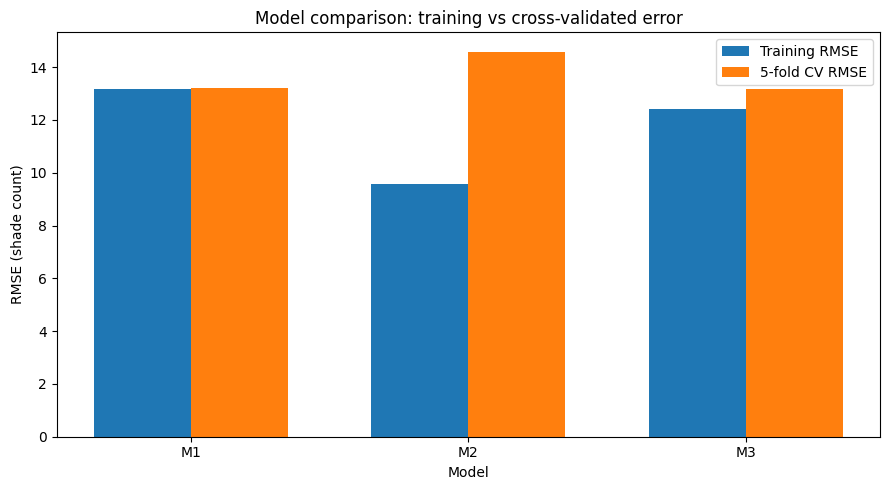

In [44]:
# Grouped bar chart: train vs CV RMSE
plot_df = comparison.set_index('model').loc[['M1', 'M2', 'M3']]

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df['train_rmse'], width, label='Training RMSE')
plt.bar(x + width/2, plot_df['cv_rmse'], width, label='5-fold CV RMSE')

plt.xticks(x, plot_df.index)
plt.ylabel('RMSE (shade count)')
plt.xlabel('Model')
plt.title('Model comparison: training vs cross-validated error')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Final model: refit on full dataset and interpret *(shared)*

Refit the selected model on all 314 product lines and report final coefficients. The year coefficient gives the estimated change in shade count per year. For M3, also list the brands whose coefficients survived LASSO.

In [ ]:
# Final model refit and interpretation
print(f"Final selected model: {best_model}")

if best_model == 'M1':
    final_model = LinearRegression().fit(X_M1, y)
    final_train_rmse = np.sqrt(mean_squared_error(y, final_model.predict(X_M1)))
    year_coef = final_model.coef_[0]
    print(f"Final year coefficient: {year_coef:.4f} shades/year")
    print(f"Final intercept: {final_model.intercept_:.4f}")
    print(f"Final training RMSE: {final_train_rmse:.4f}")

elif best_model == 'M2':
    final_model = LinearRegression().fit(X_M2, y)
    final_train_rmse = np.sqrt(mean_squared_error(y, final_model.predict(X_M2)))
    year_coef = final_model.coef_[0]
    print(f"Final year coefficient (adjusted for brand): {year_coef:.4f} shades/year")
    print(f"Final intercept: {final_model.intercept_:.4f}")
    print(f"Final training RMSE: {final_train_rmse:.4f}")

elif best_model == 'M3':
    final_model = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', LassoCV(cv=K, random_state=SEED, alphas=1000, max_iter=20000))
    ])
    final_model.fit(X_M2, y)
    final_train_rmse = np.sqrt(mean_squared_error(y, final_model.predict(X_M2)))

    lasso_final = final_model.named_steps['lasso']
    coef = lasso_final.coef_
    year_coef_std = coef[0]

    # Map brand dummy names to coefficients
    brand_dummy_cols = pd.get_dummies(product_level['brand'], drop_first=True).columns.tolist()
    brand_coefs = pd.Series(coef[1:], index=brand_dummy_cols)
    kept_brands = brand_coefs[np.abs(brand_coefs) > 1e-8].sort_values(key=np.abs, ascending=False)

    print(f"Chosen lambda (alpha): {lasso_final.alpha_:.6f}")
    print(f"Final training RMSE: {final_train_rmse:.4f}")
    print(f"Year coefficient (standardized scale): {year_coef_std:.4f}")
    print(f"Non-zero brand coefficients: {len(kept_brands)}")
    print("Brands retained by LASSO:")
    display(kept_brands.to_frame("coef"))

Final selected model: M3
Chosen lambda (alpha): 1.191922
Final training RMSE: 12.4221
Year coefficient (standardized scale): -1.2347
Non-zero brand coefficients: 20
Brands retained by LASSO:


,coef
FENTY BEAUTY by Rihanna,1.852624
MAC,0.755547
COVER FX,0.608137
It Cosmetics,-0.383296
Morphe,0.350107
UOMA Beauty,0.299912
Jouer Cosmetics,0.299912
Benefit Cosmetics,-0.283434
Josie Maran,-0.253854
Marc Jacobs Beauty,-0.234459


## 9. Results, conclusions, and discussion

We compared three models using 5-fold cross-validation at the product-line level:

- **M1**: `shade_count ~ release_year`
- **M2**: `shade_count ~ release_year + brand` (103 dummies)
- **M3**: LASSO on `release_year + brand` with λ selected by inner CV

The model comparison showed:

- **M3** had the lowest CV RMSE (**13.152**), slightly better than M1 (**13.218**) and much better than M2 (**14.589**).
- **M2** had the lowest training RMSE (**9.568**) but the largest train–CV gap (**5.021**), indicating overfitting due to high flexibility (104 predictors).
- **M3** reduced model complexity to 20 non-zero coefficients and had a much smaller train–CV gap (**0.714**), consistent with better generalization.

Based on lowest CV error, we selected **M3** as the final model. Refit on the full dataset (n = 314), M3 chose **λ = 1.2002**, had a full-data training RMSE of **12.4379**, and retained **19 brand coefficients** plus the year coefficient.

The estimated year coefficient in the selected model is **negative** (standardized-scale coefficient = **-1.2286**), and year is also negative in M1 and M2. In this sample, that means newer release years are associated with slightly lower shade counts after accounting for the included structure. Therefore, our directional hypothesis of a positive linear “Fenty Effect” (increasing shade counts over time) is **not supported** by this modeling setup.

At the same time, LASSO retained specific brand effects (e.g., FENTY BEAUTY by Rihanna, MAC, COVER FX, Morphe, UOMA Beauty, and others), which indicates meaningful **brand-level heterogeneity** in shade-range breadth. This suggests that differences across brands are a major source of variation and may partially dominate a simple linear year trend.

### Limitations
1. Approximate release dates (from Internet Archive) can introduce timing error.
2. Sample coverage depends on available scraped product pages and may not represent the full U.S. market.
3. This notebook models only **shade count**; `lightness_var` is computed but not modeled here.
4. A linear year term may be too restrictive for capturing post-2017 dynamics.

### Next steps
- Model `lightness_var` as a second outcome.
- Replace a single linear year slope with richer temporal structure (e.g., pre/post-2017 indicator, spline, or piecewise trend).
- Test interactions (e.g., year × brand group) to examine whether some brands changed faster than others.
- Run sensitivity analyses for alternate aggregation/filtering rules to assess robustness.

In [ ]:
# grade calculator 
import numpy as np
hw = [36/40, 34/40, 43.3/51, 30.5/35, 65/68, 0.8]
midterm = 14/31

final_score = 0
hw_percent = 0.5
midterm_percent = 0.2
final_exam_percent = 0.3

# calculate final score contribution from HW and midterm

final_score += np.mean(hw) * hw_percent
final_score += midterm * midterm_percent
print(f"Current final score (without final exam): {final_score:.4f} ({final_score*100:.2f}%)")

Current final score (without final exam): 0.5259 (52.59%)
